In [43]:
#DC-37 Capstone Project  - Analyze NYC OpenData - New York City Restaurants Inspection Analysis

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline



#Load data set

df = pd.read_csv("/content/NYC_Restaurant_Inspection_Results_20260.428.csv")


/tmp/ipykernel_5698/2564634664.py:13: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/content/NYC_Restaurant_Inspection_Results_20260.428.csv")


In [44]:
#Display first 10 rows of raw data

df.head(10)

,CAMIS,DBA,BORO,BUILDING,STREET,ZIPCODE,PHONE,CUISINE DESCRIPTION,INSPECTION DATE,ACTION,...,INSPECTION TYPE,Latitude,Longitude,Community Board,Council District,Census Tract,BIN,BBL,NTA,Location
0,50174294,FIVE GUYS,Manhattan,144,8 AVENUE,10011.0,5184079114,NaN,01/01/1900,NaN,...,NaN,40.741746,-74.001057,104.0,3.0,8100.0,1013844.0,1.007670e+09,MN13,POINT (-74.001057357126 40.741745617836)
1,50177452,KETTL,Brooklyn,38,NORMAN AVENUE,11222.0,9179090105,NaN,01/01/1900,NaN,...,NaN,40.724650,-73.954069,301.0,33.0,56900.0,3065946.0,3.026430e+09,BK76,POINT (-73.954069120233 40.724650265888)
2,50181336,JADE RABBIT,Manhattan,32,WEST 48 STREET,10036.0,9176884228,NaN,01/01/1900,NaN,...,NaN,40.757971,-73.979783,105.0,4.0,9600.0,1000000.0,1.012630e+09,MN17,POINT (-73.97978257519 40.757970868284)
3,50104509,CHELSEA PIERS GOLF BAR AND LOUNGEQ,Manhattan,NaN,CHELSEA PIERS,10011.0,2123366831,NaN,01/01/1900,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,50150842,CEGM (CONNECTOR LEVEL),Queens,LAGUARDIA,AIRPORT,11369.0,2159970667,NaN,01/01/1900,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,50180235,"GREAT PERFORMANCES/ARTISTS AS WAITRESSES, INC.",Manhattan,9,WEST 57 STREET,10019.0,2123376092,NaN,01/01/1900,NaN,...,NaN,40.763248,-73.974633,105.0,4.0,11201.0,1035071.0,1.012730e+09,MN17,POINT (-73.97463325396 40.763248016082)
6,50117880,FOOD LOVER BAKERY,Brooklyn,6305,20 AVENUE,11204.0,6463015998,Chinese,12/19/2025,Establishment re-opened by DOHMH.,...,Cycle Inspection / Reopening Inspection,40.617491,-73.984832,311.0,43.0,25400.0,3133259.0,3.055420e+09,BK28,POINT (-73.984832045497 40.617491406448)
7,50182163,SAMRAH COFFEE CORP.,Queens,24-09,STEINWAY STREET,11103.0,3474006350,NaN,01/01/1900,NaN,...,NaN,40.768681,-73.911063,401.0,22.0,14100.0,4011504.0,4.006860e+09,QN70,POINT (-73.911062890941 40.768681172713)
8,50182002,AUNTIE ANNE'S/CINNABON,Bronx,203,EAST FORDHAM ROAD,10458.0,7863690471,NaN,01/01/1900,NaN,...,NaN,40.862410,-73.896733,207.0,15.0,39901.0,2013607.0,2.031540e+09,BX05,POINT (-73.896732537976 40.862410460591)
9,50117478,SUNSET BAGELS,Brooklyn,8624,5 AVENUE,11209.0,7188228233,American,01/18/2024,Establishment re-opened by DOHMH.,...,Cycle Inspection / Reopening Inspection,40.621283,-74.026400,310.0,47.0,16000.0,3153556.0,3.060450e+09,BK31,POINT (-74.026400446045 40.621282660059)


In [45]:
#Display all column names

df.columns

Index(['CAMIS', 'DBA', 'BORO', 'BUILDING', 'STREET', 'ZIPCODE', 'PHONE',
       'CUISINE DESCRIPTION', 'INSPECTION DATE', 'ACTION', 'VIOLATION CODE',
       'VIOLATION DESCRIPTION', 'CRITICAL FLAG', 'SCORE', 'GRADE',
       'GRADE DATE', 'RECORD DATE', 'INSPECTION TYPE', 'Latitude', 'Longitude',
       'Community Board', 'Council District', 'Census Tract', 'BIN', 'BBL',
       'NTA', 'Location'],
      dtype='object')

In [46]:
#Display total of raw data rows count and toal of columns count
df.shape

(296585, 27)

In [47]:
#Dispaly all columns data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 296585 entries, 0 to 296584
Data columns (total 27 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   CAMIS                  296585 non-null  int64  
 1   DBA                    296583 non-null  object 
 2   BORO                   296585 non-null  object 
 3   BUILDING               295608 non-null  object 
 4   STREET                 296571 non-null  object 
 5   ZIPCODE                293427 non-null  float64
 6   PHONE                  296505 non-null  object 
 7   CUISINE DESCRIPTION    293024 non-null  object 
 8   INSPECTION DATE        296585 non-null  object 
 9   ACTION                 293120 non-null  object 
 10  VIOLATION CODE         290763 non-null  object 
 11  VIOLATION DESCRIPTION  290763 non-null  object 
 12  CRITICAL FLAG          296585 non-null  object 
 13  SCORE                  279546 non-null  float64
 14  GRADE                  146094 non-nu

In [48]:
#Checking how many miss values in each columns

df.isna().sum()


,0
CAMIS,0
DBA,2
BORO,0
BUILDING,977
STREET,14
ZIPCODE,3158
PHONE,80
CUISINE DESCRIPTION,3561
INSPECTION DATE,0
ACTION,3465


In [50]:
#Keeping only needed columns

df = df[['BORO', 'CUISINE DESCRIPTION', 'GRADE', 'SCORE']]

#Drop missing value rows
df = df.dropna()

#keeping only valide grades

df = df[df['GRADE'].isin(['A', 'B', 'C', 'P' ])]

#Clean text removing extra spaces
df['CUISINE DESCRIPTION'] = df['CUISINE DESCRIPTION'].str.strip()
df['BORO'] = df['BORO'].str.strip()

df = df.dropna()


In [51]:
#showing data with only needed columns

df.head(10)

,BORO,CUISINE DESCRIPTION,GRADE,SCORE
6,Brooklyn,Chinese,P,0.0
9,Brooklyn,American,P,0.0
17,0,American,A,12.0
44,Brooklyn,Mexican,P,0.0
56,Manhattan,Other,A,0.0
66,Queens,Hamburgers,A,0.0
102,Queens,Chicken,A,13.0
104,Brooklyn,Eastern European,P,0.0
113,Manhattan,Latin American,A,12.0
115,Queens,Pakistani,A,9.0


In [52]:
#Counting total row after dropping missing value rows

df.shape

(132300, 4)

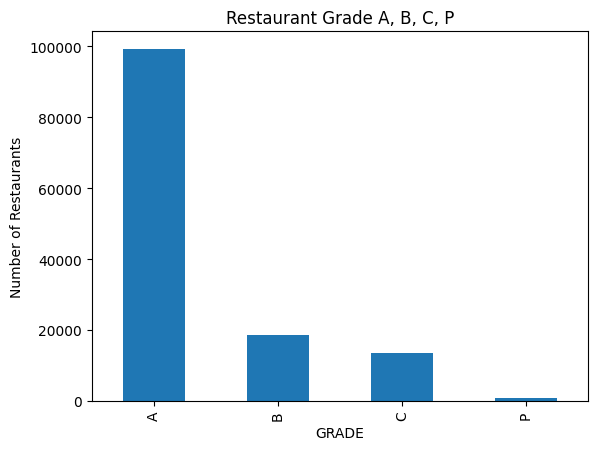

In [54]:
#Visualizaion: Compare Arrests: Manhattan vs. Brooklyn

#Prepare plot

grade_counts = df['GRADE'].value_counts()

grade_counts.plot(kind='bar')
plt.title("Restaurant Grade A, B, C, P")
plt.xlabel("GRADE")
plt.ylabel("Number of Restaurants")
plt.show()



#Conclusion : Most restaurants get A.


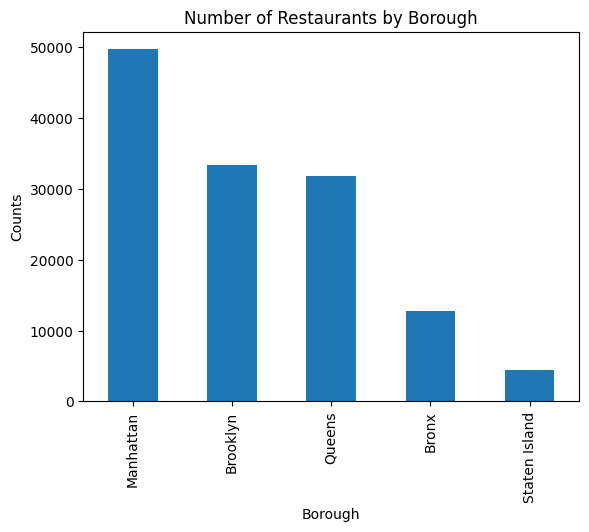

In [58]:
#Borough Comarison

df = df[df['BORO'] != '0']
boro_counts = df['BORO'].value_counts()

boro_counts.plot(kind='bar')
plt.title("Number of Restaurants by Borough")
plt.xlabel("Borough")
plt.ylabel("Counts")
plt.show()

#Conclusion : Manhattan has most the restaurants

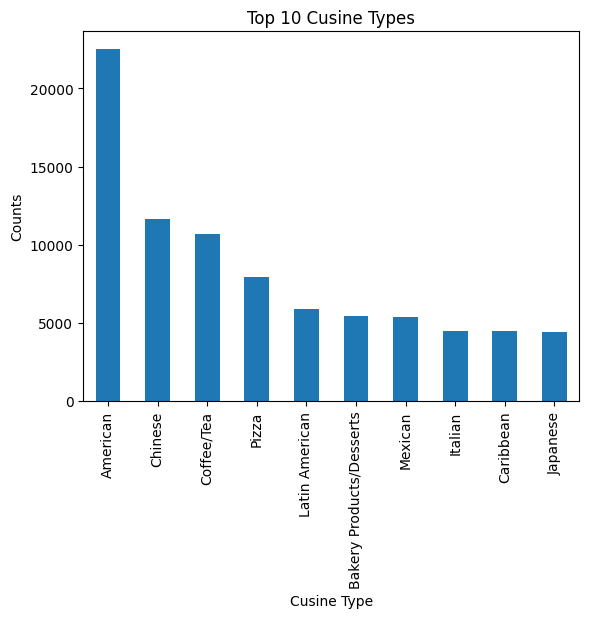

In [42]:
#Top Cusine Type

top_cuisine = df['CUISINE DESCRIPTION'].value_counts().head(10)

top_cuisine.plot(kind='bar')
plt.title("Top 10 Cusine Types")
plt.xlabel("Cusine Type")
plt.ylabel("Counts")
plt.show()

#Conclusion : American cusion is the most cusine type